In [27]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy
import PIL
import requests

In [28]:
#import the bikeshare csv 
file_name = 'Bike Share ridership 2024-01.csv' 
#without adding the encoding parameter specifying latin1, I get an error.
df = pd.read_csv(file_name, encoding='latin1')


In [29]:
#funny typo? There was a "trip  duration" rather than "trip duration". This cleans it up
df.columns = df.columns.str.strip().str.replace('  ', ' ')


In [30]:
#Start time converted to datetime object
df['Start Time'] = pd.to_datetime(df['Start Time'])

In [31]:
#filter out trips that are less than a minute long? Just a precaution if someone accidentally took a bike and changed their mind.
df = df[df['Trip Duration'] > 60]

In [32]:
#Extracting hour and day
df['Hour'] = df['Start Time'].dt.hour
df['Day'] = df['Start Time'].dt.day_name()

In [33]:
#Count rides per day and hour
heatmap_data = df.groupby(['Day', 'Hour']).size().unstack()

In [34]:
#We'll go from Monday-Sunday, so we're reordering the data.
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
heatmap_data = heatmap_data.reindex(days_order)

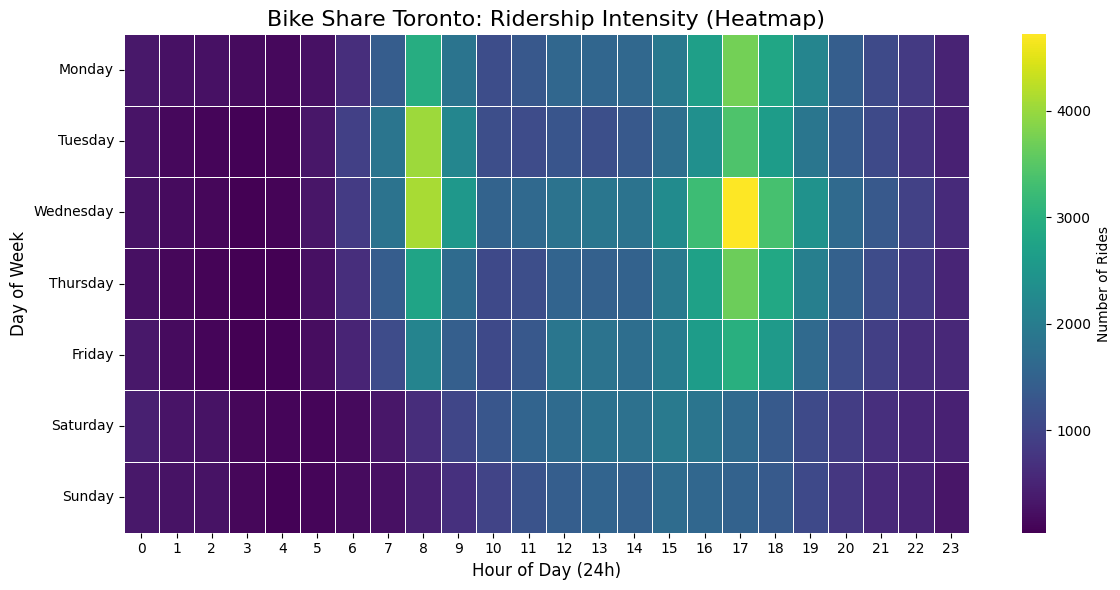

In [ ]:
plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, cmap='viridis', linewidths=.5, cbar_kws={'label': 'Number of Rides'})

plt.title('Bike Share Toronto: Ridership Intensity (Heatmap)', fontsize=18)
plt.xlabel('Hour of Day (24h)', fontsize=12)
plt.ylabel('Day of Week', fontsize=12)
plt.tight_layout()

plt.show()